[[ 1  1  1 ... -1 -1 -1]
 [ 1 -1 -1 ...  1  1  1]
 [ 1 -1 -1 ...  1  1 -1]
 ...
 [ 1  1 -1 ...  1 -1 -1]
 [-1 -1  1 ...  1 -1 -1]
 [ 1  1 -1 ...  1 -1 -1]]
[[ 1  1  1 ... -1 -1 -1]
 [ 1 -1 -1 ...  1  1  1]
 [ 1 -1 -1 ...  1  1 -1]
 ...
 [ 1  1 -1 ...  1 -1 -1]
 [-1 -1  1 ...  1 -1 -1]
 [ 1  1 -1 ...  1 -1 -1]]


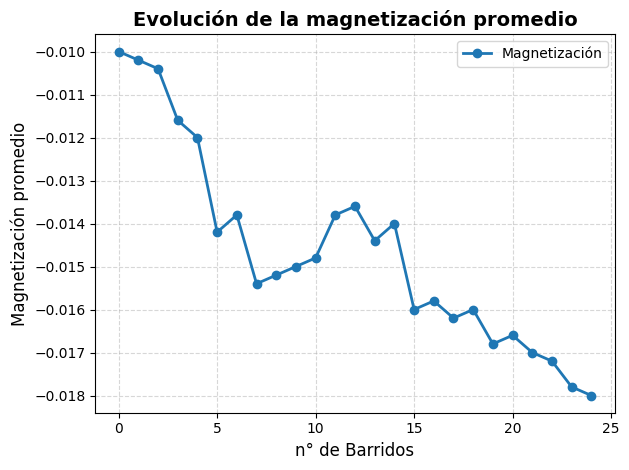

In [65]:
'''
Wolf
'''

import numpy as np 
import matplotlib.pyplot as plt 

def generador_red_inicial(N, rng): 
    red_inicial = rng.choice([-1, 1], size=(N, N)) 
    return red_inicial 

def interaccion_local(red, J, B): 
    suma_vecinos = (np.roll(red, 1, axis=0) + np.roll(red, -1, axis=0) + 
                    np.roll(red, 1, axis=1) + np.roll(red, -1, axis=1)) 
    
    delta_e = 2 * red * (J * suma_vecinos + B) 
    return delta_e 

def simular_paso_wolf(red, J, beta, rng):
    N = red.shape[0]
    i, j = rng.integers(0, N, size=2)
    direccion_semilla = red[i, j]
    
    p_add = 1.0 - np.exp(-2.0 * beta * J)
    
    pila = [(i, j)]
    red[i, j] *= -1
    
    while pila:
        curr_i, curr_j = pila.pop()

        vecinos = [
            ((curr_i + 1) % N, curr_j),
            ((curr_i - 1) % N, curr_j),
            (curr_i, (curr_j + 1) % N),
            (curr_i, (curr_j - 1) % N)
        ]
        
        for ni, nj in vecinos:
            if red[ni, nj] == direccion_semilla:
                if rng.random() < p_add:
                    pila.append((ni, nj))
                    red[ni, nj] *= -1 


def ejecutar_experimento(N, J, B, T, batchs_inactivas, batchs_activas, semilla): 
    
    if semilla is None: 
        semilla_usada = np.random.randint(0, 1000000) 
    else: 
        semilla_usada = semilla 

    rng = np.random.default_rng(semilla_usada) 
    red = generador_red_inicial(N, rng) 
    beta = 1.0 / T 
    print(red)
    
    for _ in range(batchs_inactivas): 
        simular_paso_wolf(red, J, beta, rng) 
    
    m_puntos = [] 
    for _ in range(batchs_activas): 
        simular_paso_wolf(red, J, beta, rng)  
        m_puntos.append(np.mean(red)) 
        
    return red, m_puntos, semilla_usada 

# --- CORRIDA DE CODIGO --- 
N, J, B, T = 100, 1, 1, 3 
batchs_inactivas = 0 
batchs_activas = 25
corridas = np.arange(0, batchs_activas)

red_final, m_historial, s_final = ejecutar_experimento(N, J, B, T, batchs_inactivas, batchs_activas, semilla=None)

lista_magn = np.array(m_historial).tolist()

print(red_final)


plt.plot(corridas, lista_magn, 
         marker='o', linestyle='-', linewidth=2, label='Magnetización')
plt.xlabel('n° de Barridos', fontsize=12)
plt.ylabel('Magnetización promedio', fontsize=12)
plt.title('Evolución de la magnetización promedio', fontsize=14, fontweight='bold')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
#plt.savefig(f'filtro_Aire_0,1_Polietileno Realista_0-50_Cadmio_0,1_k=1.5_Variación de la composición espectral por unidad de espesor del moderador segun espesor_practica2026CCHEN.png', dpi=300) 
plt.show()

[[ 1  1  1 ...  1  1  1]
 [-1 -1  1 ... -1 -1  1]
 [ 1  1  1 ... -1 -1  1]
 ...
 [ 1  1 -1 ... -1  1  1]
 [ 1  1  1 ...  1  1 -1]
 [-1  1  1 ...  1  1 -1]]
[[ 1  1  1 ...  1 -1  1]
 [ 1  1  1 ...  1  1  1]
 [ 1 -1  1 ...  1  1  1]
 ...
 [ 1  1  1 ...  1  1  1]
 [ 1  1  1 ...  1  1  1]
 [ 1  1  1 ...  1  1  1]]


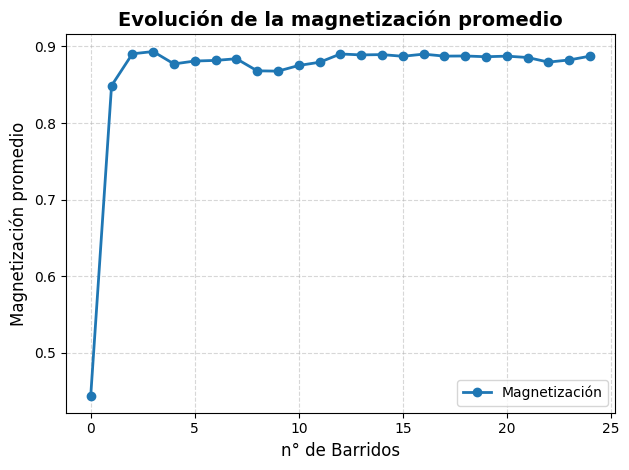

In [61]:
'''
Metropolis Vectorizado
'''


import numpy as np 
import matplotlib.pyplot as plt 

def generador_red_inicial(N, rng): 
    red_inicial = rng.choice([-1, 1], size=(N, N)) 
    return red_inicial 

def interaccion_local(red, J, B): 
    suma_vecinos = (np.roll(red, 1, axis=0) + np.roll(red, -1, axis=0) + 
                    np.roll(red, 1, axis=1) + np.roll(red, -1, axis=1)) 
    
    delta_e = 2 * red * (J * suma_vecinos + B) 
    return delta_e 

def evaluar_metropolis(delta_e, beta, rng): 
    prob_transicion = np.zeros_like(delta_e, dtype=float)
    
    mascara_positiva = delta_e > 0
    prob_transicion[mascara_positiva] = np.exp(-beta * delta_e[mascara_positiva]) 

    aleatorios = rng.random(size=delta_e.shape)
     
    aceptar = (delta_e <= 0) | (aleatorios < prob_transicion)
    return aceptar 


def simular_paso_montecarlo(red, J, B, beta, rng): 
    N = red.shape[0] 
    
    indices_i, indices_j = np.indices((N, N))
    mascara_ajedrez = (indices_i + indices_j) % 2

    for color in [0, 1]: 
        dE = interaccion_local(red, J, B) 
        
        aceptados = evaluar_metropolis(dE, beta, rng)

        mascara_final = (mascara_ajedrez == color) & aceptados
        red[mascara_final] *= -1  

def ejecutar_experimento(N, J, B, T, batchs_inactivas, batchs_activas, semilla): 
    
    if semilla is None: 
        semilla_usada = np.random.randint(0, 1000000) 
    else: 
        semilla_usada = semilla 

    rng = np.random.default_rng(semilla_usada) 
    red = generador_red_inicial(N, rng) 
    beta = 1.0 / T 
    print(red)
    for _ in range(batchs_inactivas): 
        simular_paso_montecarlo(red, J, B, beta, rng) 
    
    m_puntos = [] 
    for _ in range(batchs_activas): 
        simular_paso_montecarlo(red, J, B, beta, rng)  
        m_puntos.append(np.mean(red)) 
        
    return red, m_puntos, semilla_usada 

# --- CORRIDA DE CODIGO --- 
N, J, B, T = 100, 1, 1, 3 
batchs_inactivas = 0 
batchs_activas = 25
corridas = np.arange(0, batchs_activas)

red_final, m_historial, s_final = ejecutar_experimento(N, J, B, T, batchs_inactivas, batchs_activas, semilla=None)

lista_magn = np.array(m_historial).tolist()

print(red_final)


plt.plot(corridas, lista_magn, 
         marker='o', linestyle='-', linewidth=2, label='Magnetización')
plt.xlabel('n° de Barridos', fontsize=12)
plt.ylabel('Magnetización promedio', fontsize=12)
plt.title('Evolución de la magnetización promedio', fontsize=14, fontweight='bold')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
#plt.savefig(f'filtro_Aire_0,1_Polietileno Realista_0-50_Cadmio_0,1_k=1.5_Variación de la composición espectral por unidad de espesor del moderador segun espesor_practica2026CCHEN.png', dpi=300) 
plt.show()

[[-1 -1 -1 ...  1  1 -1]
 [ 1 -1 -1 ...  1  1  1]
 [-1 -1 -1 ... -1 -1  1]
 ...
 [-1 -1  1 ...  1 -1 -1]
 [ 1  1  1 ... -1  1 -1]
 [ 1 -1  1 ... -1  1 -1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


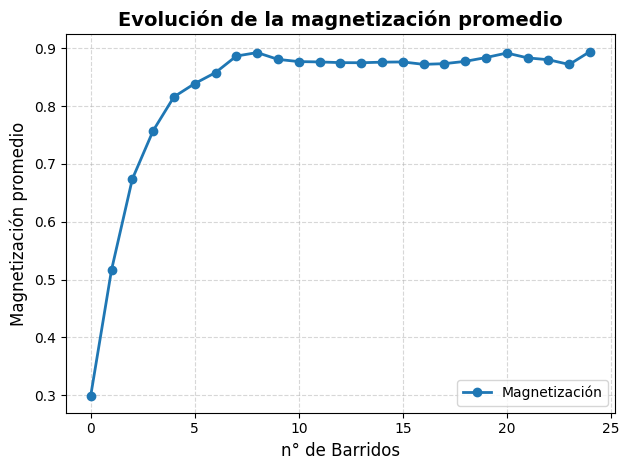

In [60]:
'''
Metropolis Normal

'''

import numpy as np
import matplotlib.pyplot as plt


def generador_red_inicial(N, rng):
    red_inicial = rng.choice([-1, 1], size=(N, N))
    return red_inicial

def interaccion_local(red, i, j, J, B):
    N = red.shape[0]
    s_i = red[i, j]
    suma_vecinos = (red[(i+1)%N, j] + red[(i-1)%N, j] +
                    red[i, (j+1)%N] + red[i, (j-1)%N])
    delta_e = 2 * s_i * (J * suma_vecinos + B)
    return delta_e

def evaluar_metropolis(delta_e, beta, rng):
    if delta_e <= 0:
        return True
    prob_transicion = np.exp(-beta * delta_e)
    return rng.random() < prob_transicion


def simular_paso_montecarlo(red, J, B, beta, rng):
    N = red.shape[0]
    num_de_eval = N * N 
    for _ in range(num_de_eval):
        i, j = rng.integers(0, N, size=2)
        dE = interaccion_local(red, i, j, J, B)
        if evaluar_metropolis(dE, beta, rng):
            red[i, j] *= -1 

def ejecutar_experimento(N, J, B, T, batchs_inactivas, batchs_activas, semilla):
    
    if semilla is None:
        semilla_usada = np.random.randint(0, 1000000)
    else:
        semilla_usada = semilla

    rng = np.random.default_rng(semilla_usada)
    red = generador_red_inicial(N, rng)
    beta = 1.0 / T
    print(red)
    
    for _ in range(batchs_inactivas):
        simular_paso_montecarlo(red, J, B, beta, rng)
    
    m_puntos = []
    for _ in range(batchs_activas):
        simular_paso_montecarlo(red, J, B, beta, rng)
        # magnetización media
        m_puntos.append(np.mean(red))
        
    return red, m_puntos, semilla_usada

# --- CORRIDA DE CODIGO --- 
N, J, B, T = 100, 1, 1, 3 
batchs_inactivas = 0 
batchs_activas = 25
corridas = np.arange(0, batchs_activas)

red_final, m_historial, s_final = ejecutar_experimento(N, J, B, T, batchs_inactivas, batchs_activas, semilla=None)

lista_magn = np.array(m_historial).tolist()

print(red_final)


plt.plot(corridas, lista_magn, 
         marker='o', linestyle='-', linewidth=2, label='Magnetización')
plt.xlabel('n° de Barridos', fontsize=12)
plt.ylabel('Magnetización promedio', fontsize=12)
plt.title('Evolución de la magnetización promedio', fontsize=14, fontweight='bold')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
#plt.savefig(f'filtro_Aire_0,1_Polietileno Realista_0-50_Cadmio_0,1_k=1.5_Variación de la composición espectral por unidad de espesor del moderador segun espesor_practica2026CCHEN.png', dpi=300) 
plt.show()